## Correlating EOP to defense genes, AMR profiles and AMR genes

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import numpy as np
from statsmodels.stats.multitest import multipletests


### Defense systems with EOP

In [68]:
#read files
defense_systems = pd.read_excel("TableS3-defenseSystems.xlsx")
eop_values = pd.read_csv("eop_raw_values.csv")

eop_long = eop_values.melt(id_vars=["EOP"], var_name="bacteria", value_name="EOP_value")
eop_long['EOP_value'] = pd.to_numeric(eop_long['EOP_value'], errors='coerce').fillna(0)

eps = 1e-6
eop_long["log_EOP"] = np.log10(eop_long["EOP_value"] + eps)


# Standardize bacteria names in eop_long to match defense_systems
eop_long['bacteria'] = eop_long['bacteria'].str.replace('A ', 'A. ')


defense_matrix = (
    defense_systems
    .pivot_table(
        index="bacteria",
        columns="subtype",
        values="genes_count",
        aggfunc="sum",   # important if a bacterium has multiple systems of same subtype
        fill_value=0
    )
    .reset_index()
)


# Merge EOP values with defense system presence/absence matrix
merged_eop_defense = pd.merge(eop_long, defense_matrix, on='bacteria', how='left')

# Fill NaNs in defense subtype columns after merging
defense_subtypes = [s for s in defense_systems["subtype"].unique() if pd.notna(s)]
merged_eop_defense[defense_subtypes] = merged_eop_defense[defense_subtypes].fillna(0)
merged_eop_defense

,EOP,bacteria,EOP_value,log_EOP,AbiU,CBASS_II,CBASS_III,Hna,Kiwa,PD-T7-1,RM_Type_I,RM_Type_II,Shedu
0,Coliflower,A. xylosoxidans jini,1.780000e+01,1.250420,0,0,0,1,0,0,0,0,0
1,Infector,A. xylosoxidans jini,2.500000e-01,-0.602058,0,0,0,1,0,0,0,0,0
2,Yaccob,A. xylosoxidans jini,3.750000e-04,-3.424812,0,0,0,1,0,0,0,0,0
3,Rage,A. xylosoxidans jini,7.690000e-08,-5.967825,0,0,0,1,0,0,0,0,0
4,Patchman,A. xylosoxidans jini,6.150000e-07,-5.791827,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,ewik,A. insolitus cram,2.500000e-06,-5.455932,0,0,5,0,3,0,0,0,0
101,maay,A. insolitus cram,2.000000e-02,-1.698948,0,0,5,0,3,0,0,0,0
102,shaaii,A. insolitus cram,5.830000e-05,-4.226945,0,0,5,0,3,0,0,0,0
103,nyashin,A. insolitus cram,2.670000e-03,-2.573326,0,0,5,0,3,0,0,0,0


In [69]:
#Aggregate EOP at the bacterium level first, since each bacteria is repeated 15 times for each phage.
#So correcting for this
bact_df = (
    merged_eop_defense
    .groupby("bacteria")
    .agg({
        "log_EOP": "mean",
        **{s: "first" for s in defense_subtypes}
    })
    .reset_index()
)


bact_df

,bacteria,log_EOP,Hna,AbiU,RM_Type_II,RM_Type_I,PD-T7-1,CBASS_II,Kiwa,Shedu,CBASS_III
0,A. insolitus aura,-9.829627e-01,0,0,2,0,0,0,2,1,5
1,A. insolitus cram,-1.415379e+00,0,0,0,0,0,0,3,0,5
2,A. insolitus neet,-9.339520e-01,0,0,0,0,0,4,2,1,5
3,A. insolitus vya,4.342943e-07,0,0,0,0,0,3,2,1,0
4,A. xylosoxidans ayb,1.358785e+00,0,0,0,0,0,0,0,0,0
5,A. xylosoxidans jini,-2.084554e+00,1,0,0,0,0,0,0,0,0
6,A. xylosoxidans suz,1.169178e+00,0,1,2,2,2,0,0,0,0


In [70]:
from scipy.stats import spearmanr

results = []

for subtype in defense_subtypes:
    rho, p = spearmanr(
        bact_df["log_EOP"],
        bact_df[subtype]
    )
    results.append([subtype, rho, p])

correlation_df_corr = pd.DataFrame(
    results,
    columns=["defense_subtype", "rho", "p"]
)
correlation_df_corr

,defense_subtype,rho,p
0,Hna,-0.612372,0.143811
1,AbiU,0.408248,0.363217
2,RM_Type_II,0.158114,0.734920
3,RM_Type_I,0.408248,0.363217
4,PD-T7-1,0.408248,0.363217
5,CBASS_II,0.133631,0.775162
6,Kiwa,-0.385758,0.392735
7,Shedu,0.000000,1.000000
8,CBASS_III,-0.433013,0.331827


In [71]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not correlation_df_corr.empty:
    reject, p_adj, _, _ = multipletests(correlation_df_corr['p'], method='fdr_bh')
    correlation_df_corr['p_adj'] = p_adj
    correlation_df_corr['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    correlation_df_corr = pd.DataFrame(columns=['defense_subtype', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

defense_corr_df_corr = correlation_df_corr
defense_corr_df_corr


,defense_subtype,rho,p,p_adj,significant
0,Hna,-0.612372,0.143811,0.589102,False
1,AbiU,0.408248,0.363217,0.589102,False
2,RM_Type_II,0.158114,0.734920,0.872057,False
3,RM_Type_I,0.408248,0.363217,0.589102,False
4,PD-T7-1,0.408248,0.363217,0.589102,False
5,CBASS_II,0.133631,0.775162,0.872057,False
6,Kiwa,-0.385758,0.392735,0.589102,False
7,Shedu,0.000000,1.000000,1.000000,False
8,CBASS_III,-0.433013,0.331827,0.589102,False


### Antibiotic reistance genes

In [72]:
amr = pd.read_csv("amrfinderplus_all.tsv", sep="\t", dtype=str).fillna("")


# ----------------------------
# Count AMR genes by Class for each bacterium
# ----------------------------
# Identify relevant columns
if "Class" in amr.columns:
    class_col = "Class"
elif "Drug Class" in amr.columns:
    class_col = "Drug Class"
else:
    raise ValueError("Could not find a 'Class' column in your AMRFinderPlus file.")

# Detect bacterium column
if "sample" in amr.columns:
    bact_col = "sample"
elif "Isolate" in amr.columns:
    bact_col = "Isolate"
else:
    raise ValueError("Could not find a bacterium identifier column (e.g., 'Sequence name').")

# Create per-bacterium counts of each AMR class
amr_counts = (
    amr.groupby([bact_col, class_col])
       .size()
       .reset_index(name="count")
       .pivot(index=bact_col, columns=class_col, values="count")
       .fillna(0)
       .reset_index()
       .rename(columns={bact_col: "bacteria"})
)

# ----------------------------
# Merge with EOP data
# ----------------------------
merged = eop_long.merge(amr_counts, on="bacteria", how="left").fillna(0)

# Get the list of AMR class columns for aggregation
amr_class_cols_for_agg = amr_counts.columns[1:].tolist()

# ----------------------------
# Aggregate EOP at the bacterium level first, since each bacteria is repeated 15 times for each phage.
# ----------------------------
amr_genes_df = (
    merged
    .groupby("bacteria")
    .agg({
        "log_EOP": "mean",
        **{s: "first" for s in amr_class_cols_for_agg}
    })
    .reset_index()
)


amr_genes_df

,bacteria,log_EOP,AMINOGLYCOSIDE,BETA-LACTAM,FOSFOMYCIN,PHENICOL,TETRACYCLINE
0,A. insolitus aura,-9.829627e-01,2.0,3.0,0.0,0.0,1.0
1,A. insolitus cram,-1.415379e+00,2.0,3.0,1.0,0.0,0.0
2,A. insolitus neet,-9.339520e-01,2.0,1.0,0.0,0.0,0.0
3,A. insolitus vya,4.342943e-07,1.0,1.0,0.0,0.0,1.0
4,A. xylosoxidans ayb,1.358785e+00,0.0,2.0,0.0,0.0,1.0
5,A. xylosoxidans jini,-2.084554e+00,1.0,2.0,0.0,1.0,0.0
6,A. xylosoxidans suz,1.169178e+00,1.0,2.0,0.0,1.0,1.0


In [101]:

# --------------------------------------------------
# Spearman correlations
# --------------------------------------------------
from scipy.stats import spearmanr

results = []

for AMRclass in amr_class_cols_for_agg:
    rho, p = spearmanr(
        amr_genes_df["log_EOP"],
        amr_genes_df[AMRclass]
    )
    results.append([AMRclass, rho, p])

amr_corr_df_corr = pd.DataFrame(
    results,
    columns=["AMR Class", "rho", "p"]
)
amr_corr_df_corr

,AMR Class,rho,p
0,AMINOGLYCOSIDE,-0.578638,0.173500
1,BETA-LACTAM,-0.377964,0.403180
2,FOSFOMYCIN,-0.408248,0.363217
3,PHENICOL,-0.158114,0.734920
4,TETRACYCLINE,0.721688,0.067106


In [103]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not amr_corr_df_corr.empty:
    reject, p_adj, _, _ = multipletests(amr_corr_df_corr['p'], method='fdr_bh')
    amr_corr_df_corr['p_adj'] = p_adj
    amr_corr_df_corr['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    amr_corr_df_corr = pd.DataFrame(columns=['AMR class', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

amrClass_corr_df_corr = amr_corr_df_corr
amrClass_corr_df_corr


,AMR Class,rho,p,p_adj,significant
0,AMINOGLYCOSIDE,-0.578638,0.173500,0.433751,False
1,BETA-LACTAM,-0.377964,0.403180,0.503975,False
2,FOSFOMYCIN,-0.408248,0.363217,0.503975,False
3,PHENICOL,-0.158114,0.734920,0.734920,False
4,TETRACYCLINE,0.721688,0.067106,0.335529,False


### Antibiotic phenotypes

In [88]:
import pandas as pd

# ----------------------------
# 1. Load data
# ----------------------------
amr = pd.read_csv("amrresults.csv")

mapping = {"R": 1, "S": 0, "I": 0.5}

bacteria_cols = amr.columns[2:].tolist()

amr_clean = amr.copy()

# IMPORTANT: force clean string formatting
amr_clean[bacteria_cols] = (
    amr_clean[bacteria_cols]
    .astype(str)
    .apply(lambda col: col.str.strip())
)

amr_numeric = amr_clean.copy()

for col in bacteria_cols:
    amr_numeric[col] = amr_numeric[col].map(mapping)

amr_numeric[bacteria_cols].isna().sum()
amr_numeric[bacteria_cols] = amr_numeric[bacteria_cols].fillna(0)

# ----------------------------
# 2. Long format
# ----------------------------
abx_long = amr_numeric.melt(
    id_vars=["Antibiotic", "Antibiotic subclass"],
    var_name="bacteria",
    value_name="resistance_score"
)


abx_subclass = (
    abx_long
    .groupby(["bacteria", "Antibiotic subclass"])["resistance_score"]
    .sum()
    .unstack(fill_value=0)
)

# ----------------------------
# 4. Collapse EOP to bacteria level
# ----------------------------
eop_bacteria = (
    eop_long
    .groupby("bacteria", as_index=False)
    .agg(mean_log_EOP=("log_EOP", "mean"))
)

# ----------------------------
# 5. Final merge
# ----------------------------
final_df = (
    eop_bacteria
    .merge(abx_subclass, on="bacteria", how="left")
    .fillna(0)
)

# ----------------------------
# 6. Output structure
# ----------------------------
abx=final_df
abx

,bacteria,mean_log_EOP,AMINOGLYCOSIDE,Anti-folate,Beta-lactam,Carbapenems,Cephalosporins,FLUROQUINOLONE,TETRACYCLINE
0,A. insolitus aura,-9.829627e-01,3.0,1.0,4.0,1.0,0.5,1.0,1.0
1,A. insolitus cram,-1.415379e+00,3.0,1.0,3.0,1.0,0.5,1.0,1.0
2,A. insolitus neet,-9.339520e-01,1.0,1.0,4.0,1.0,1.0,1.0,1.0
3,A. insolitus vya,4.342943e-07,3.0,1.0,3.0,1.0,1.0,1.0,1.0
4,A. xylosoxidans ayb,1.358785e+00,3.0,0.0,2.0,0.0,0.5,1.0,1.0
5,A. xylosoxidans jini,-2.084554e+00,3.0,0.0,2.0,0.0,0.0,1.0,1.0
6,A. xylosoxidans suz,1.169178e+00,1.5,1.0,2.0,0.0,0.0,1.0,1.0


In [97]:
abx_lis=abx_subclass.columns.to_list()
abx_lis

for xc in abx_lis:
    print(xc)

AMINOGLYCOSIDE
Anti-folate
Beta-lactam
Carbapenems
Cephalosporins
FLUROQUINOLONE
TETRACYCLINE


In [98]:

# --------------------------------------------------
# Spearman correlations
# --------------------------------------------------
from scipy.stats import spearmanr

results = []

for ABX in abx_lis:
    rho, p = spearmanr(
        abx["mean_log_EOP"],
        abx[ABX]
    )
    results.append([ABX, rho, p])

abx_corr_df_corr = pd.DataFrame(
    results,
    columns=["ABX Subclass", "rho", "p"]
)
abx_corr_df_corr

/tmp/ipykernel_6866/2734174717.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(


,ABX Subclass,rho,p
0,AMINOGLYCOSIDE,-0.267261,0.562312
1,Anti-folate,0.000000,1.000000
2,Beta-lactam,-0.264575,0.566397
3,Carbapenems,-0.288675,0.530092
4,Cephalosporins,0.188982,0.684872
5,FLUROQUINOLONE,NaN,NaN
6,TETRACYCLINE,NaN,NaN


In [99]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not abx_corr_df_corr.empty:
    reject, p_adj, _, _ = multipletests(abx_corr_df_corr['p'], method='fdr_bh')
    abx_corr_df_corr['p_adj'] = p_adj
    abx_corr_df_corr['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    abx_corr_df_corr = pd.DataFrame(columns=['ABX subclass', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

ABXSubClass_corr_df_corr = abx_corr_df_corr
ABXSubClass_corr_df_corr


,ABX Subclass,rho,p,p_adj,significant
0,AMINOGLYCOSIDE,-0.267261,0.562312,NaN,False
1,Anti-folate,0.000000,1.000000,NaN,False
2,Beta-lactam,-0.264575,0.566397,NaN,False
3,Carbapenems,-0.288675,0.530092,NaN,False
4,Cephalosporins,0.188982,0.684872,NaN,False
5,FLUROQUINOLONE,NaN,NaN,NaN,False
6,TETRACYCLINE,NaN,NaN,NaN,False


### Visualising

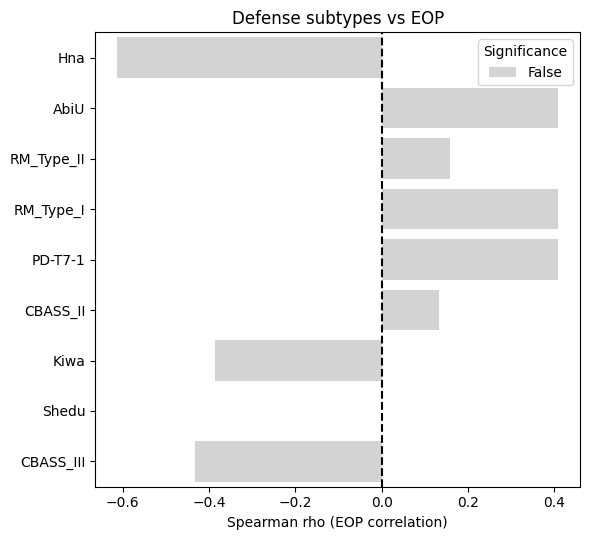

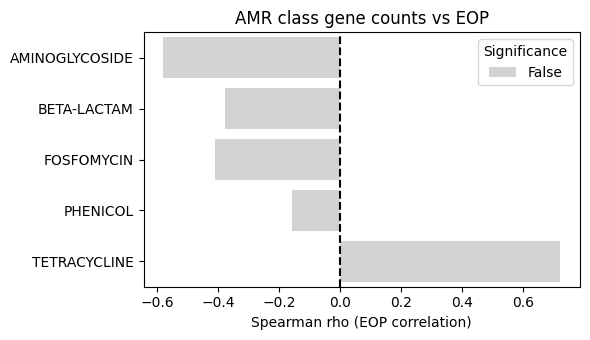

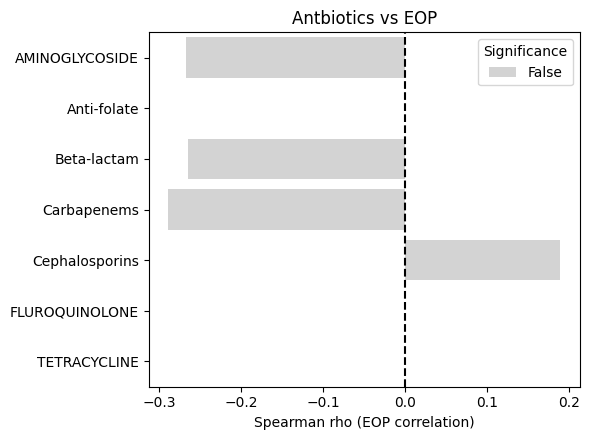

In [107]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

def plot_correlations(df, feature_col, rho_col, p_col, title):
    df = df.copy()
    df["Significance"] = df[p_col] < 0.05
    plt.figure(figsize=(6, len(df)*0.5 + 1))
    sns.barplot(data=df, x=rho_col, y=feature_col, hue="Significance",
                palette={True: "crimson", False: "lightgrey"}, dodge=False)
    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


plot_correlations(defense_corr_df_corr, "defense_subtype", "rho", "p_adj",
                  "Defense subtypes vs EOP")

plot_correlations(amrClass_corr_df_corr, "AMR Class", "rho", "p_adj",
                  "AMR class gene counts vs EOP")

plot_correlations(ABXSubClass_corr_df_corr, "ABX Subclass", "rho", "p_adj",
                  "Antbiotics vs EOP")

### Tail proteins to EOP

### Correlating EOP to Receptor binding proteins and other phage tail proteins

RBP were detected using PhageRBPDetect, https://github.com/dimiboeckaerts/PhageRBPdetection




In [117]:
# Example usage:  Replace with your desired gene IDs, from predicred PhageRBPDetect
qgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
rgeneID_subset = ["JDOEVDKM_CDS_0024", "JDOEVDKM_CDS_0028", "JDOEVDKM_CDS_0029", "AXUUMYTS_CDS_0021", "AXUUMYTS_CDS_0018", "IFXVGPNG_CDS_0028", "IFXVGPNG_CDS_0032", "IFXVGPNG_CDS_0027", "IHDRJJQR_CDS_0029", "IHDRJJQR_CDS_0034", "MPKKVJWZ_CDS_0014", "JJIYCMYV_CDS_0023", "OKILJAZK_CDS_0015", "OKILJAZK_CDS_0012", "BUBCVPIM_CDS_0027", "QLZSKYRQ_CDS_0032", "QLZSKYRQ_CDS_0029", "MOJOLAXZ_CDS_0031", "MOJOLAXZ_CDS_0024", "VCKTMGAM_CDS_0031", "VCKTMGAM_CDS_0029", "LDQZVDBU_CDS_0031", "YRFTTTDG_CDS_0017", "YRFTTTDG_CDS_0020", "VNLSRWGA_CDS_0023", "VNLSRWGA_CDS_0027", "JZFESBBW_CDS_0024"]
# Regex pattern for tail-related genes
tail_pattern = r"(tail|fiber|spike|sheath|baseplate|rbp|receptor)"

In [118]:
gene_matrix =pd.read_csv("Phage_gene_matrix.csv")
gene_matrix

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
0,ewik,Ewik_contig_1,0,1134,coliflower,Coliflower_contig_1,565,1129,100.0,1.140000e-108,terminase large subunit,AXUUMYTS_CDS_0001,terminase large subunit,JDOEVDKM_CDS_0002,ewik - AXUUMYTS_CDS_0001,ewik - AXUUMYTS_CDS_0001 - terminase large sub...,coliflower - JDOEVDKM_CDS_0002,coliflower - JDOEVDKM_CDS_0002 - terminase lar...
1,ewik,Ewik_contig_1,1136,2675,coliflower,Coliflower_contig_1,1483,2524,99.1,1.130000e-231,portal protein,AXUUMYTS_CDS_0002,portal protein,JDOEVDKM_CDS_0004,ewik - AXUUMYTS_CDS_0002,ewik - AXUUMYTS_CDS_0002 - portal protein,coliflower - JDOEVDKM_CDS_0004,coliflower - JDOEVDKM_CDS_0004 - portal protein
2,ewik,Ewik_contig_1,6569,7490,coliflower,Coliflower_contig_1,6915,8250,98.2,8.050000e-186,minor tail protein,AXUUMYTS_CDS_0005,minor tail protein,JDOEVDKM_CDS_0016,ewik - AXUUMYTS_CDS_0005,ewik - AXUUMYTS_CDS_0005 - minor tail protein,coliflower - JDOEVDKM_CDS_0016,coliflower - JDOEVDKM_CDS_0016 - minor tail pr...
3,ewik,Ewik_contig_1,8062,8494,coliflower,Coliflower_contig_1,8281,8647,97.1,5.070000e-68,Tail assembly chaperone,AXUUMYTS_CDS_0007,Tail assembly chaperone,JDOEVDKM_CDS_0017,ewik - AXUUMYTS_CDS_0007,ewik - AXUUMYTS_CDS_0007 - Tail assembly chape...,coliflower - JDOEVDKM_CDS_0017,coliflower - JDOEVDKM_CDS_0017 - Tail assembly...
4,ewik,Ewik_contig_1,9743,9293,coliflower,Coliflower_contig_1,9050,9500,99.3,1.200000e-94,tail length tape measure protein,AXUUMYTS_CDS_0008,tail completion or Neck1 protein,JDOEVDKM_CDS_0020,ewik - AXUUMYTS_CDS_0008,ewik - AXUUMYTS_CDS_0008 - tail length tape me...,coliflower - JDOEVDKM_CDS_0020,coliflower - JDOEVDKM_CDS_0020 - tail completi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8629,shaaii,Tuull_contig_1,30540,30756,nyashin,Nyashin_contig_1,31128,31356,80.0,2.190000e-42,transcriptional repressor,YRFTTTDG_CDS_0033,transcriptional repressor,BUBCVPIM_CDS_0047,shaaii - YRFTTTDG_CDS_0033,shaaii - YRFTTTDG_CDS_0033 - transcriptional r...,nyashin - BUBCVPIM_CDS_0047,nyashin - BUBCVPIM_CDS_0047 - transcriptional ...
8630,shaaii,Tuull_contig_1,33967,34723,nyashin,Nyashin_contig_1,34562,35288,65.6,1.050000e-103,hypothetical protein,YRFTTTDG_CDS_0037,hypothetical protein,BUBCVPIM_CDS_0052,shaaii - YRFTTTDG_CDS_0037,shaaii - YRFTTTDG_CDS_0037 - hypothetical protein,nyashin - BUBCVPIM_CDS_0052,nyashin - BUBCVPIM_CDS_0052 - hypothetical pro...
8631,shaaii,Tuull_contig_1,36059,36368,nyashin,Nyashin_contig_1,36699,37008,99.0,7.210000e-69,hypothetical protein,YRFTTTDG_CDS_0043,hypothetical protein,BUBCVPIM_CDS_0057,shaaii - YRFTTTDG_CDS_0043,shaaii - YRFTTTDG_CDS_0043 - hypothetical protein,nyashin - BUBCVPIM_CDS_0057,nyashin - BUBCVPIM_CDS_0057 - hypothetical pro...
8632,shaaii,Tuull_contig_1,37196,37886,nyashin,Nyashin_contig_1,38068,38608,82.6,6.230000e-99,hypothetical protein,YRFTTTDG_CDS_0045,hypothetical protein,BUBCVPIM_CDS_0061,shaaii - YRFTTTDG_CDS_0045,shaaii - YRFTTTDG_CDS_0045 - hypothetical protein,nyashin - BUBCVPIM_CDS_0061,nyashin - BUBCVPIM_CDS_0061 - hypothetical pro...


In [119]:
# If you want rsubset to be identical (as in your message)
rgeneID_subset = qgeneID_subset.copy()

# Pick which one you want to use:
selected_ids = qgeneID_subset  # or rgeneID_subset


# ---- Filtering ----

# 1. Match tail-annotated genes
tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]

# 2. Match curated list of gene IDs
list_hits = gene_matrix[gene_matrix["rgeneID"].isin(selected_ids)]

# 3. Combine (union) both sets
combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
combined_subset

/tmp/ipykernel_6866/99430094.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tail_hits = gene_matrix[gene_matrix["qgeneID"].str.contains(tail_pattern, case=False, regex=True)]


,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,qproduct,qgeneID,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name
9,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...
11,ewik,Ewik_contig_1,18329,21614,coliflower,Coliflower_contig_1,16756,19069,95.3,7.311000e-316,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,JDOEVDKM_CDS_0028,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,coliflower - JDOEVDKM_CDS_0028,coliflower - JDOEVDKM_CDS_0028 - central tail ...
67,ewik,Ewik_contig_1,17358,15213,gadget,Gadget_contig_1,13643,14699,47.7,6.250000e-87,tail fiber protein,AXUUMYTS_CDS_0018,virion structural protein,IFXVGPNG_CDS_0027,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,gadget - IFXVGPNG_CDS_0027,gadget - IFXVGPNG_CDS_0027 - virion structural...
68,ewik,Ewik_contig_1,18329,21614,gadget,Gadget_contig_1,17003,20501,94.9,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IFXVGPNG_CDS_0032,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,gadget - IFXVGPNG_CDS_0032,gadget - IFXVGPNG_CDS_0032 - central tail fiber J
107,ewik,Ewik_contig_1,18329,21614,infector,Infector_contig_1,16891,20389,100.0,0.000000e+00,central tail fiber J,AXUUMYTS_CDS_0021,central tail fiber J,IHDRJJQR_CDS_0034,ewik - AXUUMYTS_CDS_0021,ewik - AXUUMYTS_CDS_0021 - central tail fiber J,infector - IHDRJJQR_CDS_0034,infector - IHDRJJQR_CDS_0034 - central tail fi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8490,shaaii,Tuull_contig_1,17813,21809,kuwaak,Kuwaak_contig_1,15752,19250,43.9,5.310000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,MPKKVJWZ_CDS_0014,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,kuwaak - MPKKVJWZ_CDS_0014,kuwaak - MPKKVJWZ_CDS_0014 - central tail fiber J
8502,shaaii,Tuull_contig_1,15724,16849,maay,Maay_contig_1,13397,15668,31.4,8.000000e-07,tail fiber assembly,YRFTTTDG_CDS_0017,virion structural protein,OKILJAZK_CDS_0012,shaaii - YRFTTTDG_CDS_0017,shaaii - YRFTTTDG_CDS_0017 - tail fiber assembly,maay - OKILJAZK_CDS_0012,maay - OKILJAZK_CDS_0012 - virion structural p...
8508,shaaii,Tuull_contig_1,17813,21809,maay,Maay_contig_1,16603,20101,43.9,2.420000e-297,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,OKILJAZK_CDS_0015,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,maay - OKILJAZK_CDS_0015,maay - OKILJAZK_CDS_0015 - central tail fiber J
8517,shaaii,Tuull_contig_1,17813,21809,saurus,Saurus_contig_1,16496,19598,39.9,2.170000e-238,central tail fiber J,YRFTTTDG_CDS_0020,central tail fiber J,VCKTMGAM_CDS_0029,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,saurus - VCKTMGAM_CDS_0029,saurus - VCKTMGAM_CDS_0029 - central tail fiber J


In [121]:
eop_values = pd.read_csv("eop_raw_values.csv")
eop_values['EOP'] = eop_values['EOP'].str.lower()

# Melt directly from the original eop_values DataFrame
eop_long = eop_values.melt(
    id_vars=["EOP"], # Use the existing 'EOP' column as the identifier
    var_name="bacteria",
    value_name="EOP_value"
).rename(columns={"EOP": "phage"}) # Rename 'EOP' to 'phage' after melting

eop_long["log_EOP"] = np.log10(eop_long["EOP_value"] +1e+6)
combined_subset = pd.concat([tail_hits, list_hits]).drop_duplicates()
merged_subset_eop = combined_subset.merge(eop_long, left_on="queryID", right_on="phage", how="left")
merged_subset_eop

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,rproduct,rgeneID,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value,log_EOP
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0.000025,6.000000
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,3.000000,6.000001
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,400.000000,6.000174
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1.000000,6.000000
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,virion structural protein,JDOEVDKM_CDS_0024,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,2.000000,6.000001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A xylosoxidans suz,26.700000,6.000012
2180,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus vya,1.000000,6.000000
2181,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus neet,1.000000,6.000000
2182,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,central tail fiber J,LDQZVDBU_CDS_0031,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus aura,0.001670,6.000000


Code to cluster these genes using networkx

In [122]:
import networkx as nx
import pandas as pd

# Filter pairwise similarities (from your similarity file)
df = merged_subset_eop   # e.g. the phynteny or pharokka BLAST output

# Only keep strong links (e.g. ≥90% identity)
df_high = df[df["identity"] >= 90]

# Build graph
G = nx.Graph()
G.add_edges_from(df_high[["qgeneID", "rgeneID"]].itertuples(index=False, name=None))
clusters = []
for i, comp in enumerate(nx.connected_components(G), start=1):
    for gene in comp:
        clusters.append({"gene": gene, "cluster": f"cluster_{i}"})

clusters_df = pd.DataFrame(clusters)

# very important to note I AM MERGING ONLY ON QGENEID
combined_with_clusters = merged_subset_eop.merge(
    clusters_df,
    left_on="qgeneID",     # or "qgeneID"
    right_on="gene",
    how="left"
)
combined_with_clusters

,queryID,query_name,qstart,qend,refID,ref_name,rstart,rend,identity,evalue,...,merged_query,merged_query_name,merged_ref,merged_ref_name,phage,bacteria,EOP_value,log_EOP,gene,cluster
0,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans jini,0.000025,6.000000,AXUUMYTS_CDS_0018,cluster_2
1,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans ayb,3.000000,6.000001,AXUUMYTS_CDS_0018,cluster_2
2,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A xylosoxidans suz,400.000000,6.000174,AXUUMYTS_CDS_0018,cluster_2
3,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus vya,1.000000,6.000000,AXUUMYTS_CDS_0018,cluster_2
4,ewik,Ewik_contig_1,17358,15213,coliflower,Coliflower_contig_1,13545,15513,74.0,1.780000e-242,...,ewik - AXUUMYTS_CDS_0018,ewik - AXUUMYTS_CDS_0018 - tail fiber protein,coliflower - JDOEVDKM_CDS_0024,coliflower - JDOEVDKM_CDS_0024 - virion struct...,ewik,A insolitus neet,2.000000,6.000001,AXUUMYTS_CDS_0018,cluster_2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A xylosoxidans suz,26.700000,6.000012,YRFTTTDG_CDS_0020,cluster_8
2180,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus vya,1.000000,6.000000,YRFTTTDG_CDS_0020,cluster_8
2181,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus neet,1.000000,6.000000,YRFTTTDG_CDS_0020,cluster_8
2182,shaaii,Tuull_contig_1,17813,21809,turner,Turner_contig_1,15923,19025,39.9,2.140000e-238,...,shaaii - YRFTTTDG_CDS_0020,shaaii - YRFTTTDG_CDS_0020 - central tail fiber J,turner - LDQZVDBU_CDS_0031,turner - LDQZVDBU_CDS_0031 - central tail fiber J,shaaii,A insolitus aura,0.001670,6.000000,YRFTTTDG_CDS_0020,cluster_8


In [136]:
cluster_to_genes = (
    combined_with_clusters
    .groupby("cluster")["qproduct"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genes

{'cluster_1': ['central tail fiber J', 'tail fiber protein'],
 'cluster_2': ['hypothetical protein',
  'tail fiber protein',
  'virion structural protein'],
 'cluster_3': ['hypothetical protein', 'tail fiber protein'],
 'cluster_4': ['virion structural protein'],
 'cluster_5': ['central tail fiber J'],
 'cluster_6': ['membrane associated protein'],
 'cluster_7': ['central tail fiber J'],
 'cluster_8': ['central tail fiber J']}

In [128]:
df_unique = combined_with_clusters.drop_duplicates(subset=["phage", "cluster", "gene"])

cluster_table = (
    df_unique
    .groupby(["phage", "cluster"])["gene"]
    .count()
    .unstack(fill_value=0)
)

eop_phage = (
    eop_long
    .groupby("phage", as_index=False)
    .agg(mean_log_EOP=("log_EOP", "mean"))
)

phage_df = (
    cluster_table
    .merge(eop_phage, on="phage", how="left")
    .fillna(0)
)

phage_df

,phage,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,mean_log_EOP
0,bane,0,0,0,0,0,0,1,1,6.000000
1,coliflower,2,1,0,0,0,0,0,0,6.002209
2,ewik,1,1,0,0,0,0,0,0,6.000026
3,gadget,1,0,0,0,0,0,0,0,6.000024
4,infector,1,1,1,0,0,0,0,0,6.001034
5,kuwaak,1,0,0,1,0,0,0,0,6.000002
6,maay,1,0,0,1,0,0,0,0,6.000000
7,nyashin,0,0,0,0,0,0,1,1,6.000330
8,patchman,1,1,1,0,0,0,0,0,6.000000
9,rage,2,1,1,0,0,0,0,0,6.000000


In [140]:
cols = phage_df.columns.difference(["phage", "mean_log_EOP"]).tolist()
cols

['cluster_1',
 'cluster_2',
 'cluster_3',
 'cluster_4',
 'cluster_5',
 'cluster_6',
 'cluster_7',
 'cluster_8']

In [143]:

# --------------------------------------------------
# Spearman correlations
# --------------------------------------------------
from scipy.stats import spearmanr

phage_df.columns
results = []

for cluster in cols:
    rho, p = spearmanr(
        phage_df["mean_log_EOP"],
        phage_df[cluster]
    )
    results.append([cluster, rho, p])

tail_corr_df_corr = pd.DataFrame(
    results,
    columns=["Cluster", "rho", "p"]
)
tail_corr_df_corr

,Cluster,rho,p
0,cluster_1,0.273505,0.323955
1,cluster_2,0.371154,0.173193
2,cluster_3,-0.034893,0.901748
3,cluster_4,-0.363137,0.183396
4,cluster_5,0.045392,0.872383
5,cluster_6,-0.309295,0.261965
6,cluster_7,-0.181568,0.517229
7,cluster_8,-0.192879,0.490998


In [144]:
# ----- MULTIPLE TESTING CORRECTION (Benjamini–Hochberg FDR) -----
if not tail_corr_df_corr.empty:
    reject, p_adj, _, _ = multipletests(tail_corr_df_corr['p'], method='fdr_bh')
    tail_corr_df_corr['p_adj'] = p_adj
    tail_corr_df_corr['significant'] = reject   # this is FDR-adjusted significance at alpha=0.05
else:
    # If correlation_df is empty, ensure it has all expected columns to prevent KeyError later
    tail_corr_df_corr = pd.DataFrame(columns=['ABX subclass', 'spearman_rho', 'p_value', 'p_adj', 'significant'])

TailCluster_corr_df_corr = tail_corr_df_corr
TailCluster_corr_df_corr


,Cluster,rho,p,p_adj,significant
0,cluster_1,0.273505,0.323955,0.647910,False
1,cluster_2,0.371154,0.173193,0.647910,False
2,cluster_3,-0.034893,0.901748,0.901748,False
3,cluster_4,-0.363137,0.183396,0.647910,False
4,cluster_5,0.045392,0.872383,0.901748,False
5,cluster_6,-0.309295,0.261965,0.647910,False
6,cluster_7,-0.181568,0.517229,0.689639,False
7,cluster_8,-0.192879,0.490998,0.689639,False


In [145]:
cluster_to_genesID = (
    combined_with_clusters
    .groupby("cluster")["qgeneID"]
    .apply(lambda x: sorted(x.dropna().unique()))
    .to_dict()
)

cluster_to_genesID

{'cluster_1': ['AXUUMYTS_CDS_0021',
  'IFXVGPNG_CDS_0032',
  'IHDRJJQR_CDS_0034',
  'JDOEVDKM_CDS_0028',
  'JDOEVDKM_CDS_0029',
  'JZFESBBW_CDS_0030',
  'JZFESBBW_CDS_0032',
  'MOJOLAXZ_CDS_0030',
  'MOJOLAXZ_CDS_0031',
  'MPKKVJWZ_CDS_0014',
  'OKILJAZK_CDS_0015',
  'QLZSKYRQ_CDS_0032',
  'VNLSRWGA_CDS_0027',
  'VNLSRWGA_CDS_0028'],
 'cluster_2': ['AXUUMYTS_CDS_0018',
  'IHDRJJQR_CDS_0029',
  'JDOEVDKM_CDS_0024',
  'JZFESBBW_CDS_0026',
  'MOJOLAXZ_CDS_0024',
  'QLZSKYRQ_CDS_0029',
  'VNLSRWGA_CDS_0023'],
 'cluster_3': ['IHDRJJQR_CDS_0028',
  'JZFESBBW_CDS_0024',
  'MOJOLAXZ_CDS_0023',
  'QLZSKYRQ_CDS_0027'],
 'cluster_4': ['MPKKVJWZ_CDS_0012', 'OKILJAZK_CDS_0012'],
 'cluster_5': ['LDQZVDBU_CDS_0031', 'VCKTMGAM_CDS_0029'],
 'cluster_6': ['LDQZVDBU_CDS_0033'],
 'cluster_7': ['BUBCVPIM_CDS_0027', 'JJIYCMYV_CDS_0023'],
 'cluster_8': ['BUBCVPIM_CDS_0028', 'JJIYCMYV_CDS_0024', 'YRFTTTDG_CDS_0020']}

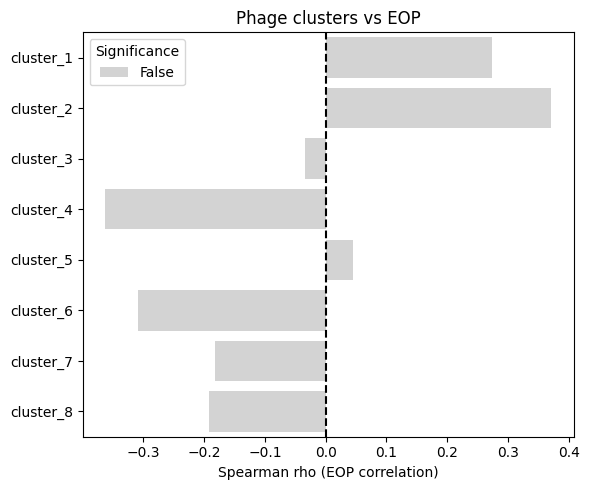

In [152]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

def plot_correlations(df, feature_col, rho_col, p_col, title, do_fdr=True):

    df = df.copy()

    # ----------------------------
    # FDR correction (Benjamini–Hochberg)
    # ----------------------------
    if do_fdr:
        reject, p_adj, _, _ = multipletests(df[p_col], method="fdr_bh")
        df["p_adj"] = p_adj
        df["Significance"] = p_adj < 0.05
        p_use = "p_adj"
    else:
        df["Significance"] = df[p_col] < 0.05
        p_use = p_col

    # ----------------------------
    # Plot
    # ----------------------------
    plt.figure(figsize=(6, len(df)*0.5 + 1))

    sns.barplot(
        data=df,
        x=rho_col,
        y=feature_col,
        hue="Significance",
        palette={True: "crimson", False: "lightgrey"},
        dodge=False
    )

    plt.axvline(0, color="black", linestyle="--")
    plt.title(title)
    plt.xlabel("Spearman rho (EOP correlation)")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

cluster_corr_df = plot_correlations(
    TailCluster_corr_df_corr,
    "Cluster",
    "rho",
    "p_adj",
    "Phage clusters vs EOP",
    do_fdr=False
)

### Tail clusters distribution plots

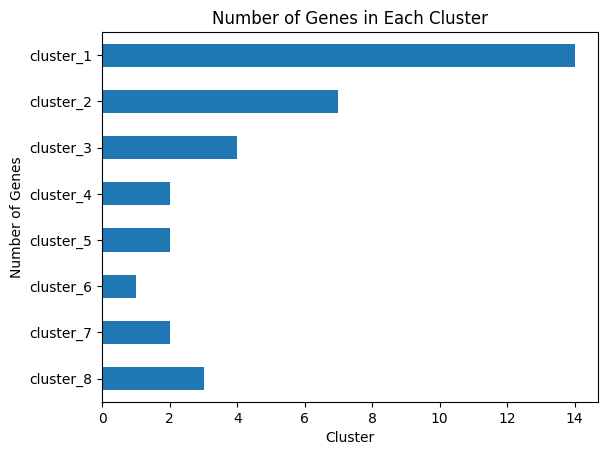

In [153]:
#plot bar graph with number of genes in each cluster
#order = ["cluster_3", "cluster_8", "cluster_4", "cluster_6", "cluster_5","cluster_7","cluster_1", "cluster_2"]
order = ["cluster_8", "cluster_7", "cluster_6", "cluster_5", "cluster_4", "cluster_3", "cluster_2", "cluster_1"]
counts = (
    combined_with_clusters
    .groupby("cluster")["gene"]   # or "Protein id", etc.
    .nunique()
)

counts = counts.reindex(order)  # reorders to your order

counts.plot(kind='barh')
plt.xlabel('Cluster')
plt.ylabel('Number of Genes')
plt.title('Number of Genes in Each Cluster')
plt.show()

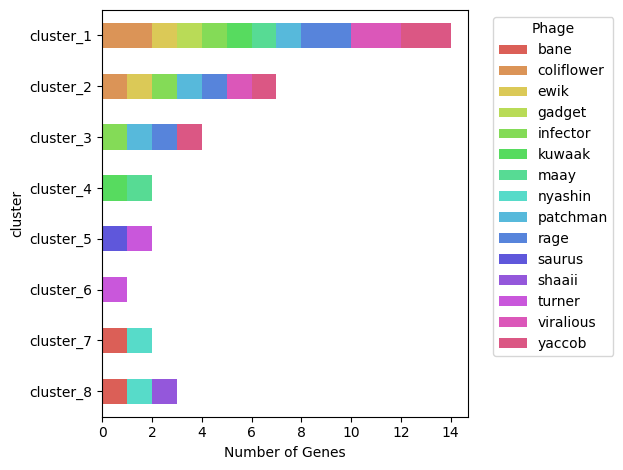

In [154]:
# function to count unique genes per group
def unique_genes(df):
    return df['gene'].nunique()  # or df['Protein id'].nunique()

stack_counts = (
    combined_with_clusters
    .groupby(["cluster", "phage"])
    .apply(unique_genes, include_groups=False)
    .reset_index(name="gene_count")
)

stack_wide = (
    stack_counts
    .pivot(index="cluster", columns="phage", values="gene_count")
    .fillna(0)
)

stack_wide = stack_wide.reindex(order)  # reorder clusters like in your first plot

stack_wide.plot(
    kind="barh",
    stacked=True,
    color=sns.color_palette("hls", 15)
)

plt.xlabel("Number of Genes")
plt.legend(title="Phage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

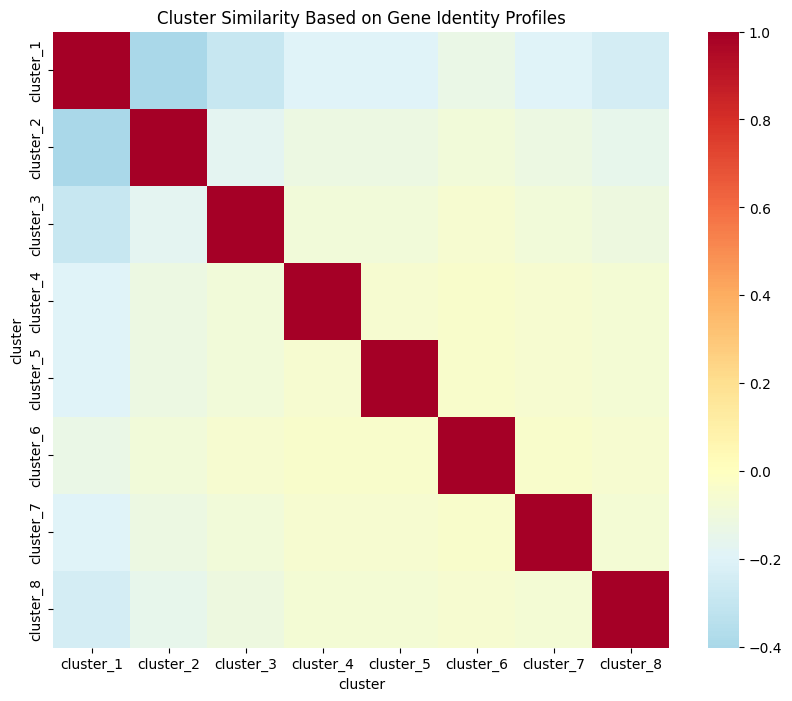

In [155]:
cluster_gene = (
    combined_with_clusters
    .pivot_table(
        index="cluster",
        columns="gene",
        values="identity",
        aggfunc="mean",
        fill_value=0
    )
)

similarity = cluster_gene.T.corr(method="pearson")

plt.figure(figsize=(10,8))

sns.heatmap(
    similarity,
    cmap="RdYlBu_r",
    center=0,
    square=True
)

plt.title("Cluster Similarity Based on Gene Identity Profiles")
plt.show()

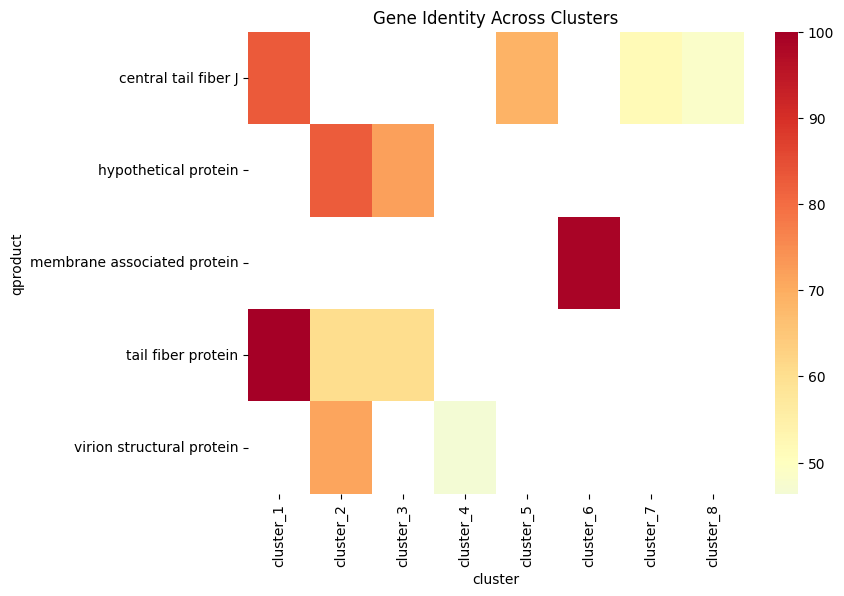

In [156]:
gene_cluster = (
    combined_with_clusters
    .pivot_table(
        index="qproduct",
        columns="cluster",
        values="identity",
        aggfunc="mean"
    )
)

plt.figure(figsize=(8,6))

sns.heatmap(
    gene_cluster,
    cmap="RdYlBu_r",
    center=50,
)

plt.title("Gene Identity Across Clusters")
plt.show()

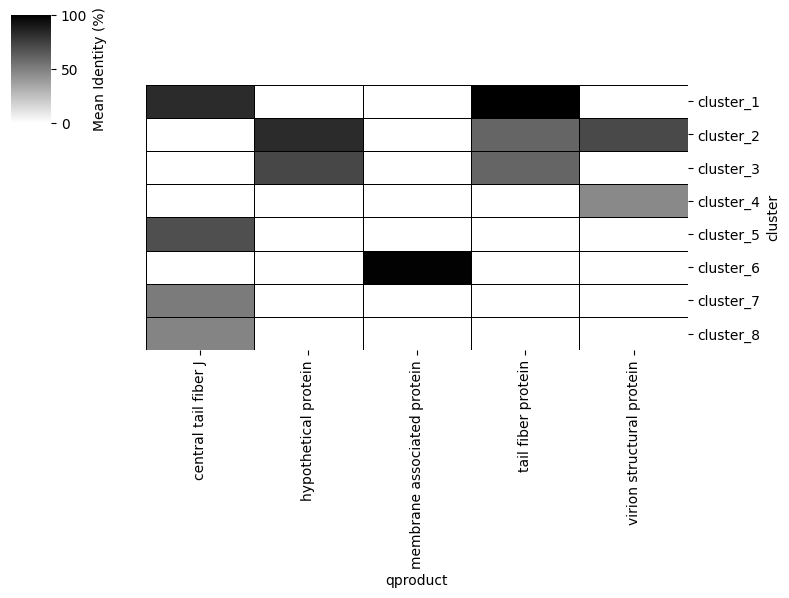

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt

gene_cluster = (
    combined_with_clusters
    .pivot_table(
        index="cluster",
        columns="qproduct",
        values="identity",
        aggfunc="mean",
        fill_value=0
    )
)

g = sns.clustermap(
    gene_cluster,
    cmap="binary",
    center=50,
    linewidths=0.5,
    linecolor="black",
    figsize=(8, 6),
    row_cluster=False,
    col_cluster=False,
    cbar_kws={"label": "Mean Identity (%)"}

)

plt.show()

In [158]:
rbp_genes = set(qgeneID_subset)  # same as rgeneID_subset
rbp_genes

{'AXUUMYTS_CDS_0018',
 'AXUUMYTS_CDS_0021',
 'BUBCVPIM_CDS_0027',
 'IFXVGPNG_CDS_0027',
 'IFXVGPNG_CDS_0028',
 'IFXVGPNG_CDS_0032',
 'IHDRJJQR_CDS_0029',
 'IHDRJJQR_CDS_0034',
 'JDOEVDKM_CDS_0024',
 'JDOEVDKM_CDS_0028',
 'JDOEVDKM_CDS_0029',
 'JJIYCMYV_CDS_0023',
 'JZFESBBW_CDS_0024',
 'LDQZVDBU_CDS_0031',
 'MOJOLAXZ_CDS_0024',
 'MOJOLAXZ_CDS_0031',
 'MPKKVJWZ_CDS_0014',
 'OKILJAZK_CDS_0012',
 'OKILJAZK_CDS_0015',
 'QLZSKYRQ_CDS_0029',
 'QLZSKYRQ_CDS_0032',
 'VCKTMGAM_CDS_0029',
 'VCKTMGAM_CDS_0031',
 'VNLSRWGA_CDS_0023',
 'VNLSRWGA_CDS_0027',
 'YRFTTTDG_CDS_0017',
 'YRFTTTDG_CDS_0020'}

In [159]:
#checking each cluster
cluster_check = {}

for cluster, genes in cluster_to_genesID.items():
    genes = set(genes)
    missing = genes - rbp_genes

    if len(missing) == 0:
        cluster_check[cluster] = {
            "all_in_rbp_list": True,
            "missing_genes": None
        }
    else:
        cluster_check[cluster] = {
            "all_in_rbp_list": False,
            "missing_genes": sorted(missing)
        }


In [160]:
for cluster, result in cluster_check.items():
    if result["all_in_rbp_list"]:
        print(f"Cluster {cluster}: TRUE (all genes are predicted RBPs)")
    else:
        print(f"Cluster {cluster}: FALSE")
        print(f"  Missing genes: {', '.join(result['missing_genes'])}")


Cluster cluster_1: FALSE
  Missing genes: JZFESBBW_CDS_0030, JZFESBBW_CDS_0032, MOJOLAXZ_CDS_0030, VNLSRWGA_CDS_0028
Cluster cluster_2: FALSE
  Missing genes: JZFESBBW_CDS_0026
Cluster cluster_3: FALSE
  Missing genes: IHDRJJQR_CDS_0028, MOJOLAXZ_CDS_0023, QLZSKYRQ_CDS_0027
Cluster cluster_4: FALSE
  Missing genes: MPKKVJWZ_CDS_0012
Cluster cluster_5: TRUE (all genes are predicted RBPs)
Cluster cluster_6: FALSE
  Missing genes: LDQZVDBU_CDS_0033
Cluster cluster_7: TRUE (all genes are predicted RBPs)
Cluster cluster_8: FALSE
  Missing genes: BUBCVPIM_CDS_0028, JJIYCMYV_CDS_0024
